### 뼈대 코드 gt 시각화 해보기 

✅ Y_tensor 복구 완료! 형태: torch.Size([297, 51])


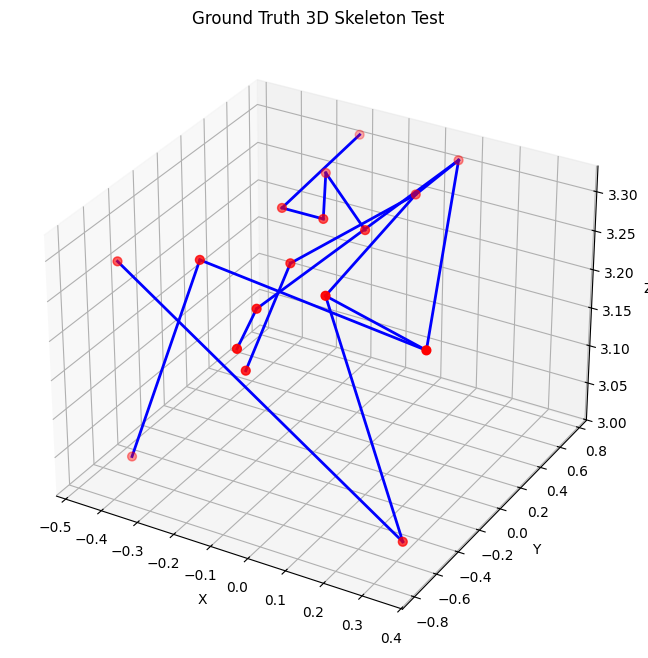

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ====================================================
# 1. Y_tensor 복구하기 (단일 파일 로드)
# ====================================================
# ⚠️ 파일 경로는 네 실제 폴더 위치에 맞게 살짝 수정해줘!
gt_path = "E01/S01/A02/ground_truth.npy" 
gt_data = np.load(gt_path) # 불러온 원본 형태: (297, 17, 3)

# 17개의 3D 좌표를 1차원으로 쫙 펴기 (Flatten)
Y_flat = gt_data.reshape(gt_data.shape[0], -1) 

# PyTorch 텐서로 변환
Y_tensor = torch.tensor(Y_flat, dtype=torch.float32)
print("✅ Y_tensor 복구 완료! 형태:", Y_tensor.shape) # 기대값: torch.Size([297, 51])


# ====================================================
# 2. 뼈대(Skeleton) 시각화 테스트
# ====================================================
# 17개 관절 연결선 규칙 (MM-Fi 기준)
bones = [(0,1), (0,2), (1,3), (2,4), (5,6), (5,7), (7,9), (6,8), (8,10),
         (5,11), (6,12), (11,12), (11,13), (13,15), (12,14), (14,16)]

def plot_gt_only(gt_pose):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # 텐서라면 넘파이(NumPy)로 변환
    if isinstance(gt_pose, torch.Tensor):
        gt_pose = gt_pose.cpu().numpy()
        
    # (51,) 형태를 다시 (17, 3) 3D 좌표로 접기
    gt_pose = gt_pose.reshape(17, 3)
    
    # 뼈대(선) 그리기
    for bone in bones:
        ax.plot([gt_pose[bone[0], 0], gt_pose[bone[1], 0]],
                [gt_pose[bone[0], 1], gt_pose[bone[1], 1]],
                [gt_pose[bone[0], 2], gt_pose[bone[1], 2]], 'b-', linewidth=2)
        
    # 관절(점) 찍기
    ax.scatter(gt_pose[:, 0], gt_pose[:, 1], gt_pose[:, 2], c='red', s=40)
    
    ax.set_title("Ground Truth 3D Skeleton Test")
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.show()

# 🎯 0번째 프레임 정답지 뼈대 그려보기!
plot_gt_only(Y_tensor[0])